In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

In [ ]:
# plot appearance default parameters
mpl.rc('lines', linewidth=0.4)
mpl.rc('font', family="Helvetica", size=8, )
mpl.rc('axes', labelsize=8, titlesize=8, linewidth=0.4)
mpl.rc('legend', fontsize=8)
mpl.rc('xtick', labelsize=8)
mpl.rc('xtick.major', width=0.4, size=2)
mpl.rc('xtick.minor', width=0.4, size=1)
mpl.rc('ytick', labelsize=10)
mpl.rc('ytick.major', width=0.4, size=2)
mpl.rc('ytick.minor', width=0.4, size=1)
mpl.rcParams['pdf.fonttype'] = 42
mpl.font_manager.weight_dict['roman'] = 400

In [ ]:
# the dataframe comes from STRING Web tool output, containing reactome pathways results
df = pd.read_csv('../data/2_1_enrichment_PS_genes.tsv', sep='\t', header=0)
df

,#term ID,term description,observed gene count,background gene count,strength,signal,false discovery rate,matching proteins in your network (IDs),matching proteins in your network (labels)
0,HSA-8948216,Collagen chain trimerization,7,40,1.03,0.48,0.0161,"9606.ENSP00000300527,9606.ENSP00000351767,9606...","COL6A2,COL20A1,COL18A1,COL4A2,COL6A1,COL4A1,CO..."
1,HSA-419037,NCAM1 interactions,6,31,1.07,0.46,0.0223,"9606.ENSP00000300527,9606.ENSP00000320025,9606...","COL6A2,CACNB2,COL4A2,COL6A1,COL4A1,COL9A3"
2,HSA-2022090,Assembly of collagen fibrils and other multime...,7,52,0.92,0.43,0.0249,"9606.ENSP00000252804,9606.ENSP00000300527,9606...","PXDN,COL6A2,COL18A1,COL4A2,COL6A1,COL4A1,COL9A3"
3,HSA-1474290,Collagen formation,8,77,0.80,0.40,0.0281,"9606.ENSP00000252804,9606.ENSP00000300527,9606...","PXDN,COL6A2,COL20A1,COL18A1,COL4A2,COL6A1,COL4..."
4,HSA-186797,Signaling by PDGF,6,39,0.97,0.42,0.0281,"9606.ENSP00000300527,9606.ENSP00000346508,9606...","COL6A2,PDGFA,COL4A2,COL6A1,COL4A1,COL9A3"
5,HSA-1442490,Collagen degradation,6,47,0.89,0.36,0.0447,"9606.ENSP00000300527,9606.ENSP00000352798,9606...","COL6A2,COL18A1,COL4A2,COL6A1,COL4A1,COL9A3"
6,HSA-1474228,Degradation of the extracellular matrix,8,94,0.72,0.34,0.0455,"9606.ENSP00000300527,9606.ENSP00000352798,9606...","COL6A2,COL18A1,COL4A2,MMP17,COL6A1,COL4A1,FBN2..."


/tmp/ipykernel_302966/814916728.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("YlOrBr_r")   # reversed so small FDR is darker
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


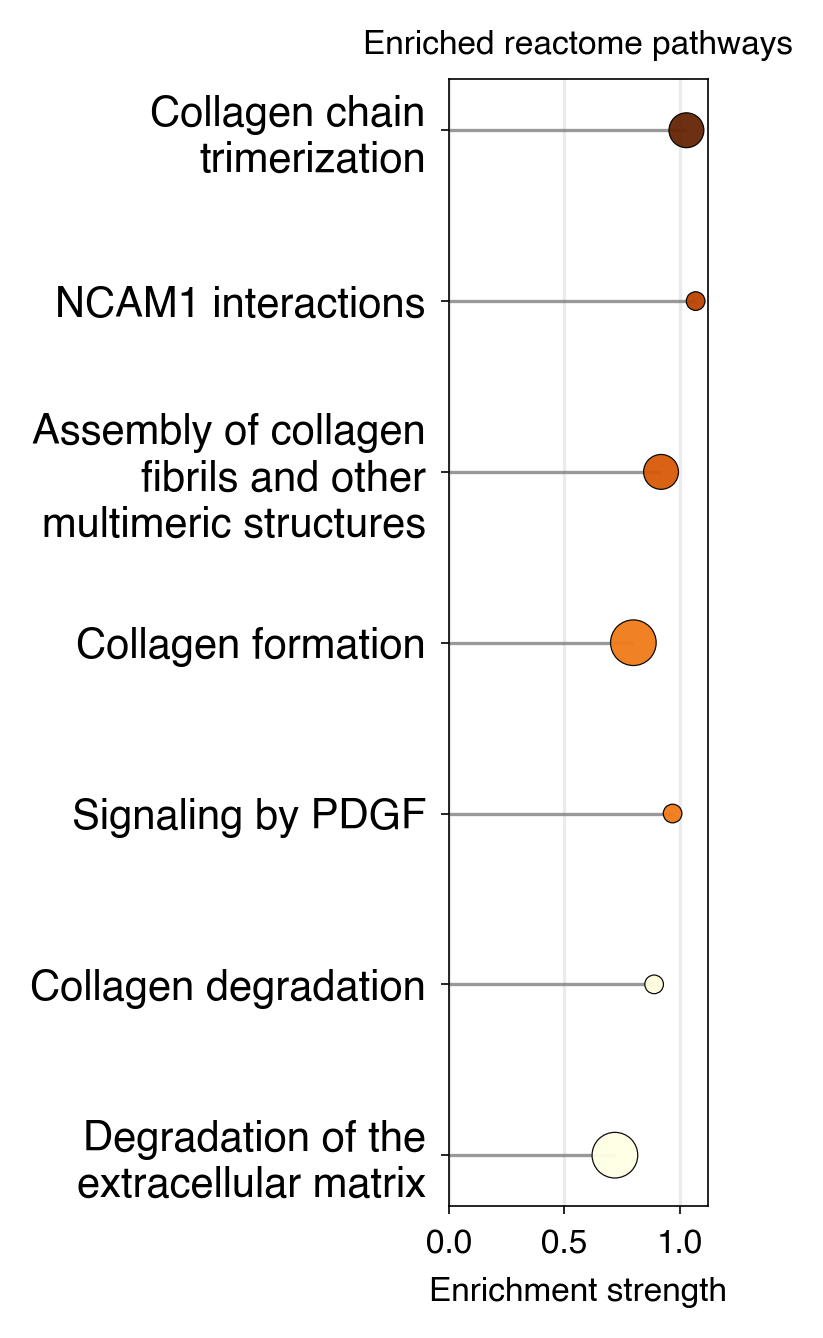

In [ ]:
# top terms
df_plot = df.sort_values("false discovery rate").copy()

# wrap long labels
df_plot["term_short"] = df_plot["term description"].str.wrap(24)

# y positions (most significant on top)
y = np.arange(len(df_plot))[::-1]

x = df_plot["strength"].to_numpy(dtype=float)
counts = df_plot["observed gene count"].to_numpy(dtype=float)

# sizes mapped to counts
s_min, s_max = 20, 120
if counts.max() == counts.min():
    s = np.full_like(counts, (s_min + s_max) / 2, dtype=float)
else:
    s = s_min + (counts - counts.min()) / (counts.max() - counts.min()) * (s_max - s_min)

# FDR as a color
fdr = df_plot["false discovery rate"].to_numpy(dtype=float)
cmap = mpl.cm.get_cmap("YlOrBr_r")   # reversed so small FDR is darker
norm = mpl.colors.Normalize(vmin=fdr.min(), vmax=fdr.max())

fig, ax = plt.subplots(figsize=(2.5, 4.5), dpi=300)

# transparent background
fig.patch.set_alpha(0)
ax.set_facecolor("none")

# lollipop lines (0 -> x)
for yi, xi in zip(y, x):
    ax.hlines(yi, 0, xi, color="#6F6F6F", linewidth=0.8, alpha=0.7)

# points
sc = ax.scatter(
    x, y,
    c=fdr,
    s=s,
    cmap=cmap,
    norm=norm,
    alpha=0.95,
    linewidth=0.3,
    edgecolor="black",
    zorder=3
)

# axes formatting
ax.set_xlim(0, float(x.max()) * 1.05)
ax.set_xlabel("Enrichment strength")
ax.set_yticks(y)
ax.set_xticks([0, 0.5, 1])
ax.set_yticklabels(df_plot["term_short"])
ax.set_ylabel("")
ax.grid(True, axis="x", alpha=0.25)
ax.set_axisbelow(True)
ax.set_title("Enriched reactome pathways", fontweight="bold")

plt.tight_layout()
plt.savefig("../plots/enrichment_lollipop_fdr.pdf", transparent=True, bbox_inches="tight", dpi=300)
plt.show()

/tmp/ipykernel_1859718/1559357375.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("YlOrBr_r")
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


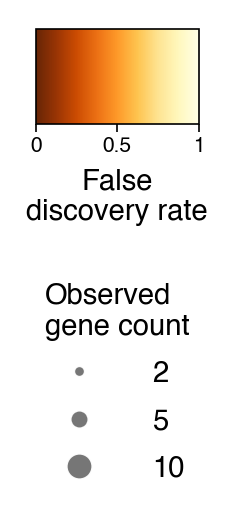

In [ ]:
## legend figure: colorbar (FDR) + size legend (gene count)

# functions
def map_size(val, vmin, vmax, smin, smax):
    if vmax == vmin:
        return (smin + smax) / 2
    return smin + (val - vmin) / (vmax - vmin) * (smax - smin)

# basic parameters
fig, axes = plt.subplots(2, 1, figsize=(0.7, 2), dpi=300,
                          gridspec_kw={'height_ratios': [1, 2.5], 'hspace': 0.8})
fig.patch.set_alpha(0)

cmap = mpl.cm.get_cmap("YlOrBr_r")
norm = mpl.colors.Normalize(vmin=0, vmax=1)

## colorbar 
ax_cb = axes[0]
ax_cb.set_facecolor("none")
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, cax=ax_cb, orientation="horizontal")

cbar.set_ticks([0, 0.5, 1])
cbar.set_ticklabels(["0", "0.5", "1"])
cbar.ax.tick_params(labelsize=5, pad=1)
cbar.set_label("False\ndiscovery rate", fontsize=7, labelpad=3)
cbar.outline.set_linewidth(0.4)

gridspec_kw={'height_ratios': [2, 2.5], 'hspace': 0.8}

## size legend
ax_sz = axes[1]
ax_sz.set_facecolor("none")
ax_sz.axis("off")

#dot size
s_min, s_max = 20, 120 # dot size limits
reps = [2, 5, 10] # gene counts

sizes = [map_size(v, min(reps), max(reps), s_min, s_max) for v in reps] # each gene count get a dot size

handles = [
    plt.Line2D([], [], linestyle="none", marker="o",
               markersize=np.sqrt(s) / 1.8,
               markerfacecolor="#6F6F6F",
               markeredgecolor="white",
               markeredgewidth=0.4,
               alpha=0.95)
    for s in sizes
]
ax_sz.legend(handles, [str(v) for v in reps],
             title="Observed\ngene count",
             loc="upper center",
             frameon=False,
             labelspacing=0.7,
             handletextpad=1.5,
             fontsize=7,
             title_fontsize=7)

plt.savefig("../plots/legend_fdr_size.pdf", transparent=True, bbox_inches="tight")
plt.show()